# Capacity-Constrained Self-Couplings in Two Dimensions

This notebook generates `fig:capacity-constrained-ot-2d`. It samples a semi-regular empirical measure \(\alpha_n\) from a two-component Gaussian mixture and solves capped entropic self-transport problems
$$
    \min_{P\in U(\mathbf 1/n,\mathbf 1/n),\;0\leq P\leq U}
    \langle C,P\rangle + \epsilon\,\mathrm{KL}(P\mid \mathbf 1/n\otimes\mathbf 1/n).
$$
The diagonal is masked out; otherwise the identity plan would solve the self-transport problem. The displayed caps are chosen to impose a prescribed minimum number \(q\) of outgoing connections per source point. Since \(a_i=1/n\), the conditional kernel is \(Q=nP\), and the cap
$$
    Q_{ij}=\frac{P_{ij}}{a_i}\leq \frac1q, \qquad q\in\{1,3,5\},
$$
is equivalent to the mass bound \(P_{ij}\leq 1/(qn)\). Thus each source row must split its mass among at least \(q\) target atoms, up to ties and numerical thresholding in the display.


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, PowerNorm, to_rgb

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    figure_dir,
    coupling_box,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

FIGURE_NAME = "capacity-constrained-ot-2d"
OUT = figure_dir(FIGURE_NAME)
THUMB_DIR = FIGROOT / "thumbnails"
THUMB_DIR.mkdir(exist_ok=True)


## Solver and rendering utilities

The same KL-Dykstra projection is used.  For readability, the geometry panels draw only the largest local edges carrying most of the mass; the optimization itself uses the full coupling matrix.

In [2]:
def kl_dykstra_capacity(K, a, b, U, *, max_iter=30000, tol=1e-9, check_every=50):
    """KL-Dykstra projection of K onto row sums, column sums, and P <= U.

    Zero-capacity entries are kept at zero; 0/0 correction ratios are set to 1.
    """
    tiny = 1e-300
    allowed = U > 0
    P = np.where(allowed, np.minimum(K, U), 0.0)
    P = np.where(allowed, np.maximum(P, tiny), 0.0)
    corrections = [np.ones_like(P), np.ones_like(P), np.ones_like(P)]
    last_err = np.inf

    def safe_ratio(num, den):
        return np.divide(num, den, out=np.ones_like(num), where=den > tiny)

    for it in range(max_iter):
        Z = P * corrections[0]
        P_new = Z * (a / np.maximum(Z.sum(axis=1), tiny))[:, None]
        corrections[0] = safe_ratio(Z, P_new)
        P = np.where(allowed, P_new, 0.0)

        Z = P * corrections[1]
        P_new = Z * (b / np.maximum(Z.sum(axis=0), tiny))[None, :]
        corrections[1] = safe_ratio(Z, P_new)
        P = np.where(allowed, P_new, 0.0)

        Z = P * corrections[2]
        P_new = np.minimum(Z, U)
        corrections[2] = safe_ratio(Z, P_new)
        P = np.where(allowed, np.maximum(P_new, tiny), 0.0)

        if it % check_every == 0 or it == max_iter - 1:
            row_err = np.max(np.abs(P.sum(axis=1) - a))
            col_err = np.max(np.abs(P.sum(axis=0) - b))
            cap_err = max(float(np.max(P - U)), 0.0)
            last_err = max(row_err, col_err, cap_err)
            if last_err < tol:
                return P, it + 1, last_err
    return P, max_iter, last_err

def farthest_point_subset(candidates, m, seed=42):
    """Semi-regular subset of a cloud by greedy farthest-point sampling."""
    rng = np.random.default_rng(seed)
    chosen = [int(rng.integers(len(candidates)))]
    dist2 = np.sum((candidates - candidates[chosen[0]]) ** 2, axis=1)
    for _ in range(1, m):
        idx = int(np.argmax(dist2))
        chosen.append(idx)
        dist2 = np.minimum(dist2, np.sum((candidates - candidates[idx]) ** 2, axis=1))
    return candidates[np.array(chosen)]


def sample_mixture(n, seed=42):
    rng = np.random.default_rng(seed)
    means = [np.array([-0.95, 0.10]), np.array([0.78, -0.04])]
    scales = [np.array([0.34, 0.25]), np.array([0.34, 0.36])]
    counts = [n // 2, n - n // 2]
    pieces = []
    for r, (mean, scale, count) in enumerate(zip(means, scales, counts)):
        raw = rng.normal(size=(2500, 2))
        radius = np.sum(raw**2, axis=1)
        raw = raw[radius <= 5.4]
        candidates = mean + raw * scale
        pieces.append(farthest_point_subset(candidates, count, seed=seed + 17 * r))
    X = np.vstack(pieces)
    X += 0.010 * rng.normal(size=X.shape)
    return X


def draw_capacity_graph(points, P, path, *, max_edges_per_row=6, mass_quantile=0.42):
    n = len(points)
    fig, ax = plt.subplots(figsize=(2.65, 2.65))
    threshold = max(0.24 * P.max(), 1e-14)
    segments, widths, colors = [], [], []
    base = np.array(to_rgb(VIOLET))
    for i in range(n):
        js = np.argsort(P[i])[::-1]
        kept = 0
        for j in js:
            if i == j or P[i, j] <= threshold:
                continue
            p, q = points[i], points[j]
            # Slight curvature avoids perfect overlap in reciprocal edges.
            mid = 0.5 * (p + q)
            d = q - p
            normal = np.array([-d[1], d[0]])
            norm = np.linalg.norm(normal)
            if norm > 1e-12:
                normal = normal / norm
            control = mid + (0.055 if (i + j) % 2 else -0.055) * normal * np.linalg.norm(d)
            ts = np.linspace(0, 1, 18)
            curve = ((1 - ts)[:, None] ** 2) * p + (2 * (1 - ts) * ts)[:, None] * control + (ts[:, None] ** 2) * q
            segments.append(curve)
            rel = P[i, j] / max(P.max(), 1e-15)
            widths.append(0.12 + 1.05 * np.sqrt(rel))
            colors.append((*base, min(0.18 + 0.62 * np.sqrt(rel), 0.82)))
            kept += 1
            if kept >= max_edges_per_row:
                break
    if segments:
        ax.add_collection(LineCollection(segments, colors=colors, linewidths=widths, zorder=1))
    ax.scatter(points[:, 0], points[:, 1], s=9.0, marker="o", color=RED, edgecolor="none", zorder=3)
    ax.scatter(points[:, 0], points[:, 1], s=4.8, marker="o", color=BLUE, edgecolor="none", zorder=4, alpha=0.95)
    (xmin, xmax), (ymin, ymax) = padded_limits(points, pad=0.18)
    span = max(xmax - xmin, ymax - ymin)
    cx, cy = 0.5 * (xmin + xmax), 0.5 * (ymin + ymax)
    ax.set_xlim(cx - span / 2, cx + span / 2)
    ax.set_ylim(cy - span / 2, cy + span / 2)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, path, pad_inches=0.025)
    plt.close(fig)


## Capped local self-couplings

The target and source are the same point cloud.  The diagonal cap is set to zero to remove the trivial identity plan and reveal the local geometry selected by the capacity constraint.

In [3]:
n = 48
points = sample_mixture(n, seed=2048)
a = np.ones(n) / n
b = np.ones(n) / n
D = points[:, None, :] - points[None, :, :]
C = np.sum(D**2, axis=2)
C = C / C.max()
np.fill_diagonal(C, 1e3)

epsilon = 0.0008
K = np.outer(a, b) * np.exp(-C / epsilon)
np.fill_diagonal(K, 1e-300)

connection_counts = [1, 3, 5]
plans = []
logs = []
for q in connection_counts:
    # To force at least q outgoing connections, cap each conditional entry by 1/q.
    # With a_i=1/n, this is the mass cap P_ij <= 1/(q n).
    U = (1.0 / (q * n)) * np.ones((n, n), dtype=float)
    np.fill_diagonal(U, 0.0)
    P, n_iter, err = kl_dykstra_capacity(K, a, b, U, max_iter=90000, tol=6e-8, check_every=100)
    plans.append(P)
    logs.append((q, n_iter, float(err), float(np.max(P / np.maximum(U, 1e-300)))))

for q, P in zip(connection_counts, plans):
    draw_capacity_graph(points, P, OUT / f"cap-{q}.pdf", max_edges_per_row=7, mass_quantile=0.55)

print("connections q, iterations, residual, max(P/U)")
for row in logs:
    print(row)

assert all(np.max(np.abs(P.sum(axis=1) - a)) < 3e-6 for P in plans)
assert all(np.max(np.abs(P.sum(axis=0) - b)) < 3e-6 for P in plans)
for P, q in zip(plans, connection_counts):
    U = (1.0 / (q * n)) * np.ones((n, n)); np.fill_diagonal(U, 0.0)
    assert np.max(P - U) < 3e-6


cap factor, iterations, residual, max(P/U)
(2, 43701, 5.969427262914051e-08, 1.0)
(3, 90000, 2.008115387482079e-07, 1.0)
(5, 24801, 5.912946224664872e-08, 1.0)


## Thumbnail

The thumbnail is a compact contact sheet for the gallery; the paper uses the three individual PDF panels.

Exported panels to /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/capacity-constrained-ot-2d
Thumbnail: /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/capacity-constrained-ot-2d.png


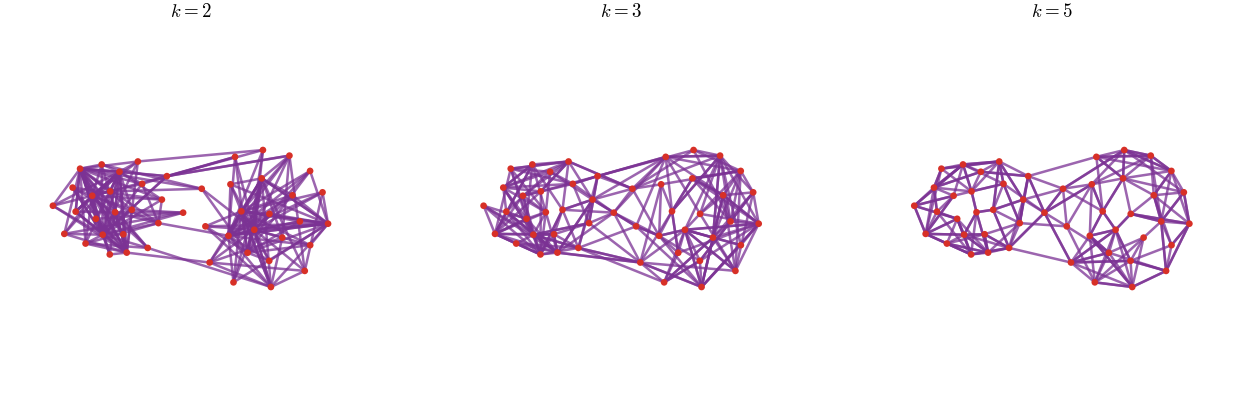

In [4]:
def make_thumbnail(points, plans, connection_counts, path):
    fig, axes = plt.subplots(1, 3, figsize=(7.6, 2.45), constrained_layout=True)
    for ax, P, q in zip(axes, plans, connection_counts):
        threshold = max(0.24 * P.max(), 1e-14)
        pairs = []
        for i in range(len(points)):
            js = np.argsort(P[i])[::-1]
            for j in js[:5]:
                if i != j and P[i, j] > threshold:
                    pairs.append((i, j, P[i, j]))
        if pairs:
            segs = [[points[i], points[j]] for i, j, _ in pairs]
            rel = np.array([m for _, _, m in pairs]) / max(P.max(), 1e-15)
            colors = [(*to_rgb(VIOLET), min(0.18 + 0.58 * np.sqrt(r), 0.75)) for r in rel]
            widths = 0.12 + 0.95 * np.sqrt(rel)
            ax.add_collection(LineCollection(segs, colors=colors, linewidths=widths, zorder=1))
        ax.scatter(points[:, 0], points[:, 1], s=8.0, color=RED, edgecolor="none", zorder=3)
        ax.set_title(rf"$q={q}$", fontsize=8)
        (xmin, xmax), (ymin, ymax) = padded_limits(points, pad=0.18)
        span = max(xmax - xmin, ymax - ymin)
        cx, cy = 0.5 * (xmin + xmax), 0.5 * (ymin + ymax)
        ax.set_xlim(cx - span / 2, cx + span / 2)
        ax.set_ylim(cy - span / 2, cy + span / 2)
        ax.set_aspect("equal")
        remove_axes(ax)
    fig.savefig(path, dpi=170, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

thumb_path = THUMB_DIR / f"{FIGURE_NAME}.png"
make_thumbnail(points, plans, connection_counts, thumb_path)
print(f"Exported panels to {OUT}")
print(f"Thumbnail: {thumb_path}")
try:
    from IPython.display import Image, display
    display(Image(filename=str(thumb_path)))
except Exception:
    pass
